# Running FilterZyme on data from serine hydrolase paper

## Prep input data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

data = pd.read_csv('serine_hydrolase_data.csv')

df_long = data.melt(
    id_vars=["name", "aa_seq"],         
    var_name="substrate_name",    
    value_name="activity"         
)

# remove empty rows
df = df_long.dropna(subset=["activity"])
df.rename(columns={'aa_seq': 'Sequence'}, inplace=True)

# make entry column
df['Entry'] = df['name'] + "_" + df['substrate_name']

# add smile string etc
smile_dict = {
    "probe": "CN(C)C1=CC2C(C=C1)C(C3=C(C([O-])=O)C=C(C(NCCCCCCCCCCP(OCC)(F)=O)=O)C=C3)=C4C=CC(N(C)C)=CC4=[O+]2",
    "sing_4MUAc": "CC(C1=CC=C(OC(C)=O)C=C1O2)=CC2=O",
    "act_4MUAc": "CC(C1=CC=C(OC(C)=O)C=C1O2)=CC2=O",
    "ing_4MUBu": "CC(C1=CC=C(OC(CCC)=O)C=C1O2)=CC2=O",
    "act_4MUBu": "CC(C1=CC=C(OC(CCC)=O)C=C1O2)=CC2=O",  
}

moiety_dict = {
    "probe": "[#6]-[P](=O)(O)(O)",
    "sing_4MUAc": "[CX3;!R](=O)O[#6;!R]",
    "act_4MUAc": "[CX3;!R](=O)O[#6;!R]",
    "ing_4MUBu": "[CX3;!R](=O)O[#6;!R]",
    "act_4MUBu": "[CX3;!R](=O)O[#6;!R]",
}

df['substrate_smiles'] = df['substrate_name'].map(smile_dict)  
df['substrate_moiety'] = df['substrate_name'].map(moiety_dict)
df['cofactor_name'] = None

# clean amino acid sequence

def clean_sequence(seq: str) -> str:

    if pd.isna(seq):
        return None
    seq = seq.upper()
    seq = re.sub(r'[^ACDEFGHIKLMNPQRSTVWY]', '', seq)  # Keep only standard 20 amino acids
    return seq

df['Sequence'] = df['Sequence'].apply(clean_sequence)
df

#df.to_pickle('serine_hydrolases_input_df.pkl')

/tmp/ipykernel_1067629/2211879548.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'aa_seq': 'Sequence'}, inplace=True)
/tmp/ipykernel_1067629/2211879548.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Entry'] = df['name'] + "_" + df['substrate_name']
/tmp/ipykernel_1067629/2211879548.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

,name,Sequence,substrate_name,activity,Entry,substrate_smiles,substrate_moiety,cofactor_name
16,4ess_A,ARIRDVQGDITEFQGDAIVNAANNYLKLGAGVAGAILRKGGPSIQE...,probe,True,4ess_A_probe,CN(C)C1=CC2C(C=C1)C(C3=C(C([O-])=O)C=C(C(NCCCC...,[#6]-[P](=O)(O)(O),None
17,4ess_A,ARIRDVQGDITEFQGDAIVNAANNYLKLGAGVAGAILRKGGPSIQE...,probe,True,4ess_A_probe,CN(C)C1=CC2C(C=C1)C(C3=C(C([O-])=O)C=C(C(NCCCC...,[#6]-[P](=O)(O)(O),None
18,4etk_A,ARIRAVQGDITEFQGDAIVNAANNYLKLGAGVAGAILRKGGPSIQE...,probe,True,4etk_A_probe,CN(C)C1=CC2C(C=C1)C(C3=C(C([O-])=O)C=C(C(NCCCC...,[#6]-[P](=O)(O)(O),None
19,4jca_A,RIRHVQGDITEFQGDAIVNAANNYLKLGAGVAGAILRKGGPSIQEE...,probe,True,4jca_A_probe,CN(C)C1=CC2C(C=C1)C(C3=C(C([O-])=O)C=C(C(NCCCC...,[#6]-[P](=O)(O)(O),None
20,5JXG_A,VYQEPTDPKFPQQWYLSGVTQRDLNVKAAWAQGYTGHHGIVVSILD...,probe,True,5JXG_A_probe,CN(C)C1=CC2C(C=C1)C(C3=C(C([O-])=O)C=C(C(NCCCC...,[#6]-[P](=O)(O)(O),None
...,...,...,...,...,...,...,...,...
4191,bird,MLDKEQRIALAAEVTSLYDELLERGLAAADLPADYSGFTRQEHSAT...,act_4MUBu,False,bird_act_4MUBu,CC(C1=CC=C(OC(CCC)=O)C=C1O2)=CC2=O,[CX3;!R](=O)O[#6;!R],None
4192,yes2,MLNKEERRKLADEVTSIYDSLLEKGLEKGNLPKDYIGYTKEEHHKA...,act_4MUBu,False,yes2_act_4MUBu,CC(C1=CC=C(OC(CCC)=O)C=C1O2)=CC2=O,[CX3;!R](=O)O[#6;!R],None
4196,epic,GEAAREAFFGEAEEYVEVVSQAYDNLLRKGLPELTDEWTTAHHATV...,act_4MUBu,False,epic_act_4MUBu,CC(C1=CC=C(OC(CCC)=O)C=C1O2)=CC2=O,[CX3;!R](=O)O[#6;!R],None
4198,kill,MTLTDEEFSELIVTTTQKFDSILKKGYEKSPDKEGIINKINKSFNI...,act_4MUBu,False,kill_act_4MUBu,CC(C1=CC=C(OC(CCC)=O)C=C1O2)=CC2=O,[CX3;!R](=O)O[#6;!R],None


## Analyze FilterZyme Results

In [2]:
import pandas as pd
import seaborn as sns
import plotting_utils as pu
import sys

sys.path.insert(0, '/nvme2/helen/EnzymeStructuralFiltering/')
import filterzyme
from filterzyme.utils.helpers import clean_plt

pastel_blue = "#aec7e8"
PALETTE_grey_blue = sns.blend_palette(["darkgrey", pastel_blue], as_cmap=True)


results_df = pd.read_pickle('/nvme2/helen/EnzymeStructuralFiltering/benchmarking/serine_hydrolases/filterzyme_output/geometricfiltering/structural_features_final.pkl')

boltz_only =  results_df[results_df['tool'] == 'boltz']
chai_only = results_df[results_df['tool'] == 'chai']
first_only = results_df[results_df['is_first'] == True]

activity_map = dict(zip(results_df['Entry'], results_df['activity']))
results_df_avg_all = results_df.groupby("Entry", as_index=False).mean(numeric_only=True)
results_df_std_all = results_df.groupby("Entry", as_index=False).std(numeric_only=True) #standard deviations of means of all structures per entry
results_df_avg_all['activity'] = results_df_avg_all['Entry'].map(activity_map)
results_df_std_all['activity'] = results_df_std_all['Entry'].map(activity_map)

results_df_feature_means = results_df_avg_all.drop(columns=["Entry", "activity"]).mean()
results_df_feature_stds  = results_df_std_all.drop(columns=["Entry", "activity"]).mean() # Average standard deviations across entries

results_df_std_all_by_activity = results_df_std_all.groupby("activity",  as_index=False).mean(numeric_only=True)

In [3]:
feature_columns = [
'chai-chai_mean_proteinRMSD',
'chai-chai_std_proteinRMSD',
'boltz-chai_mean_proteinRMSD',
'boltz-chai_std_proteinRMSD',
'boltz-boltz_mean_proteinRMSD',
'boltz-boltz_std_proteinRMSD',
'entry_overall_mean_proteinRMSD',
'entry_overall_std_proteinRMSD',
'chai_aggregate_score',
'chai_ptm',
'chai_iptm',
'boltz2_confidence_score',
'boltz2_ptm',
'boltz2_iptm',
'boltz2_ligand_iptm',
'boltz2_protein_iptm',
'boltz2_complex_plddt',
'boltz2_complex_iplddt',
'boltz2_complex_pde',
'boltz2_complex_ipde',
'boltz2_affinity_pred_value',
'boltz2_affinity_probability_binary',
'boltz2_affinity_pred_value1',
'boltz2_affinity_probability_binary1',
'boltz2_affinity_pred_value2',
'boltz2_affinity_probability_binary2',
'boltz_boltz_mean_ligandRMSD',
'boltz_boltz_std_ligandRMSD',
'boltz_chai_mean_ligandRMSD',
'boltz_chai_std_ligandRMSD',
'chai_chai_mean_ligandRMSD',
'chai_chai_std_ligandRMSD',
'overall_ligandRMSD_mean',
'overall_ligandRMSD_std',
'fpocket_Pocket_Score',
'fpocket_Drug_Score',
'fpocket_Num_alpha_spheres',
'fpocket_Mean_alpha_sphere_radius',
'fpocket_Mean_alpha_sphere_Solvent_Acc',
'fpocket_Mean_B_factor',
'fpocket_Hydrophobicity_Score',
'fpocket_Polarity_Score',
'fpocket_Amino_Acid_based_volume_Score',
'fpocket_Pocket_volume_Monte_Carlo',
'fpocket_Pocket_volume_convex_hull',
'fpocket_Charge_Score',
'fpocket_Local_hydrophobic_density_Score',
'fpocket_Num_apolar_alpha_sphere',
'fpocket_Proportion_apolar_alpha_sphere',
'total_sasa',
'polar_sasa',
'apolar_sasa',
'sasa_ligand_in_complex',
'sasa_ligand_alone',
'buried_sasa',
'percentage_buried_sasa',
'plip_hydrogen_nbonds',
'plip_hydrophobic_contacts',
'plip_salt_bridges',
'plip_pi_stacking',
'plip_pi_cation',
'plip_halogen_bonds',
'plip_water_bridges',
'plip_metal_complexes',
'distance_ligand_to_closest_nuc',
]

missing_columns_chai = ['boltz2_confidence_score', 'boltz2_ptm', 'boltz2_iptm', 'boltz2_ligand_iptm', 'boltz2_protein_iptm', 'boltz2_complex_plddt', 
                    'boltz2_complex_ipde', 'boltz2_complex_iplddt', 'boltz2_complex_pde','boltz2_affinity_pred_value', 'boltz2_affinity_probability_binary', 
                    'boltz2_affinity_pred_value1', 'boltz2_affinity_probability_binary1', 'boltz2_affinity_pred_value2', 'boltz2_affinity_probability_binary2']

missing_columns_boltz = ['chai_aggregate_score', 'chai_ptm', 'chai_iptm']

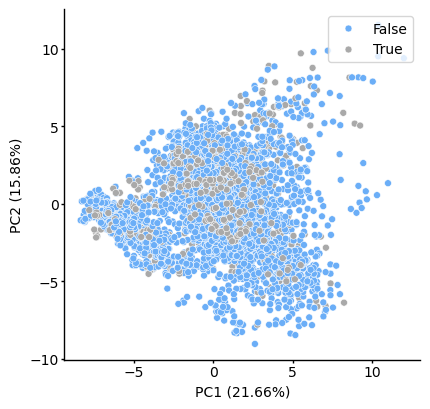

top PC1 loadings: fpocket_Pocket_volume_Monte_Carlo    0.250202
sasa_ligand_in_complex               0.241627
total_sasa                           0.237583
sasa_ligand_alone                    0.234930
percentage_buried_sasa               0.231382
overall_ligandRMSD_mean              0.231337
boltz_chai_mean_ligandRMSD           0.214187
polar_sasa                           0.206462
fpocket_Pocket_volume_convex_hull    0.206421
apolar_sasa                          0.201003
Name: PC1, dtype: float64
top PC2 loadings: fpocket_Num_apolar_alpha_sphere            0.334612
fpocket_Num_alpha_spheres                  0.305096
buried_sasa                                0.298972
fpocket_Local_hydrophobic_density_Score    0.281335
plip_hydrophobic_contacts                  0.266351
fpocket_Drug_Score                         0.217642
fpocket_Pocket_Score                       0.200380
fpocket_Proportion_apolar_alpha_sphere     0.196756
fpocket_Pocket_volume_convex_hull          0.195713
fpocket_Hy

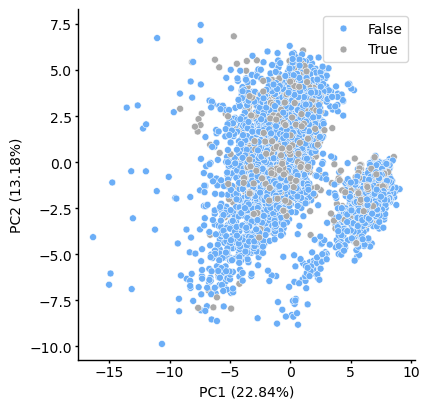

top PC1 loadings: boltz2_confidence_score              0.222446
boltz2_complex_iplddt                0.215522
boltz2_complex_plddt                 0.213873
sasa_ligand_alone                    0.211927
fpocket_Pocket_volume_Monte_Carlo    0.211845
sasa_ligand_in_complex               0.202732
percentage_buried_sasa               0.193632
total_sasa                           0.190839
boltz2_complex_pde                   0.186252
boltz2_affinity_pred_value           0.174712
Name: PC1, dtype: float64
top PC2 loadings: fpocket_Num_apolar_alpha_sphere            0.326480
buried_sasa                                0.316127
fpocket_Num_alpha_spheres                  0.313549
fpocket_Local_hydrophobic_density_Score    0.272660
plip_hydrophobic_contacts                  0.257934
fpocket_Pocket_Score                       0.236917
fpocket_Pocket_volume_convex_hull          0.207644
fpocket_Drug_Score                         0.205933
fpocket_Proportion_apolar_alpha_sphere     0.171614
fpocket_Hy

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt


label_column = 'activity'
dPALETTE_grey_blue = ["#6baef7", "darkgrey"]

def visualize_PCA(df, feature_columns, missing_columns, label_column, tool, note, set_NaN_zero = False, ):
    label_column = label_column

    s2 = set(missing_columns)        
    feature_columns = [x for x in feature_columns if x not in s2]

    if tool == None: 
        df_normalized = df.loc[:,feature_columns + [label_column]].copy()
    else: 
        df_normalized = df.loc[df["tool"] == tool, feature_columns + [label_column]].copy()
    if set_NaN_zero == True: 
        df_normalized[feature_columns] = df_normalized[feature_columns].fillna(0)

    df_normalized.dropna(inplace=True)
    feature_columns = [c for c in feature_columns if c in df_normalized.columns]
    X = df_normalized[feature_columns].to_numpy()  
    y = df_normalized[label_column].to_numpy()    

    # standardize features using standard normalization i.e. mean=0 and variance=1
    scaler = StandardScaler()
    X_scaled  = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=2, svd_solver="full", random_state=0)
    X_pca = pca.fit_transform(X_scaled)   

    # plot
    pca_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], label_column: y})
    exp_var_pct = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(4.4, 4.2))
    ax = sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=label_column, alpha = 1, s=25, palette=dPALETTE_grey_blue)
    ax.set_xlabel(f"PC1 ({exp_var_pct[0]:.2f}%)")
    ax.set_ylabel(f"PC2 ({exp_var_pct[1]:.2f}%)")
    #ax.set_title(f"PCA of standardized features ({tool} - {note})")
    clean_plt(ax) 
    plt.legend(frameon=True, loc = 'upper right', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.savefig(f'/nvme2/helen/masterthesis/3_manuscript/figures/PCA_overview_DEDB_{tool}_{note.replace(" ", "_")}.png', dpi=300)
    plt.show()
    

    # extract loadings

    # Loadings: each row is a PC, each column a feature
    loadings = pd.DataFrame(
        pca.components_.T, 
        index=feature_columns, 
        columns=[f'PC{i+1}' for i in range(pca.n_components_)]
    )

    # sort by absolute contribution
    top_PC1 = loadings['PC1'].abs().sort_values(ascending=False).head(10)
    top_PC2 = loadings['PC2'].abs().sort_values(ascending=False).head(10)
    print(f'top PC1 loadings: {top_PC1}')
    print(f'top PC2 loadings: {top_PC2}')


visualize_PCA(results_df, feature_columns, missing_columns_chai, 'activity', 'chai', 'first structures only', set_NaN_zero=True)
visualize_PCA(results_df, feature_columns, missing_columns_boltz, 'activity', 'boltz', 'first structures only', set_NaN_zero=True)


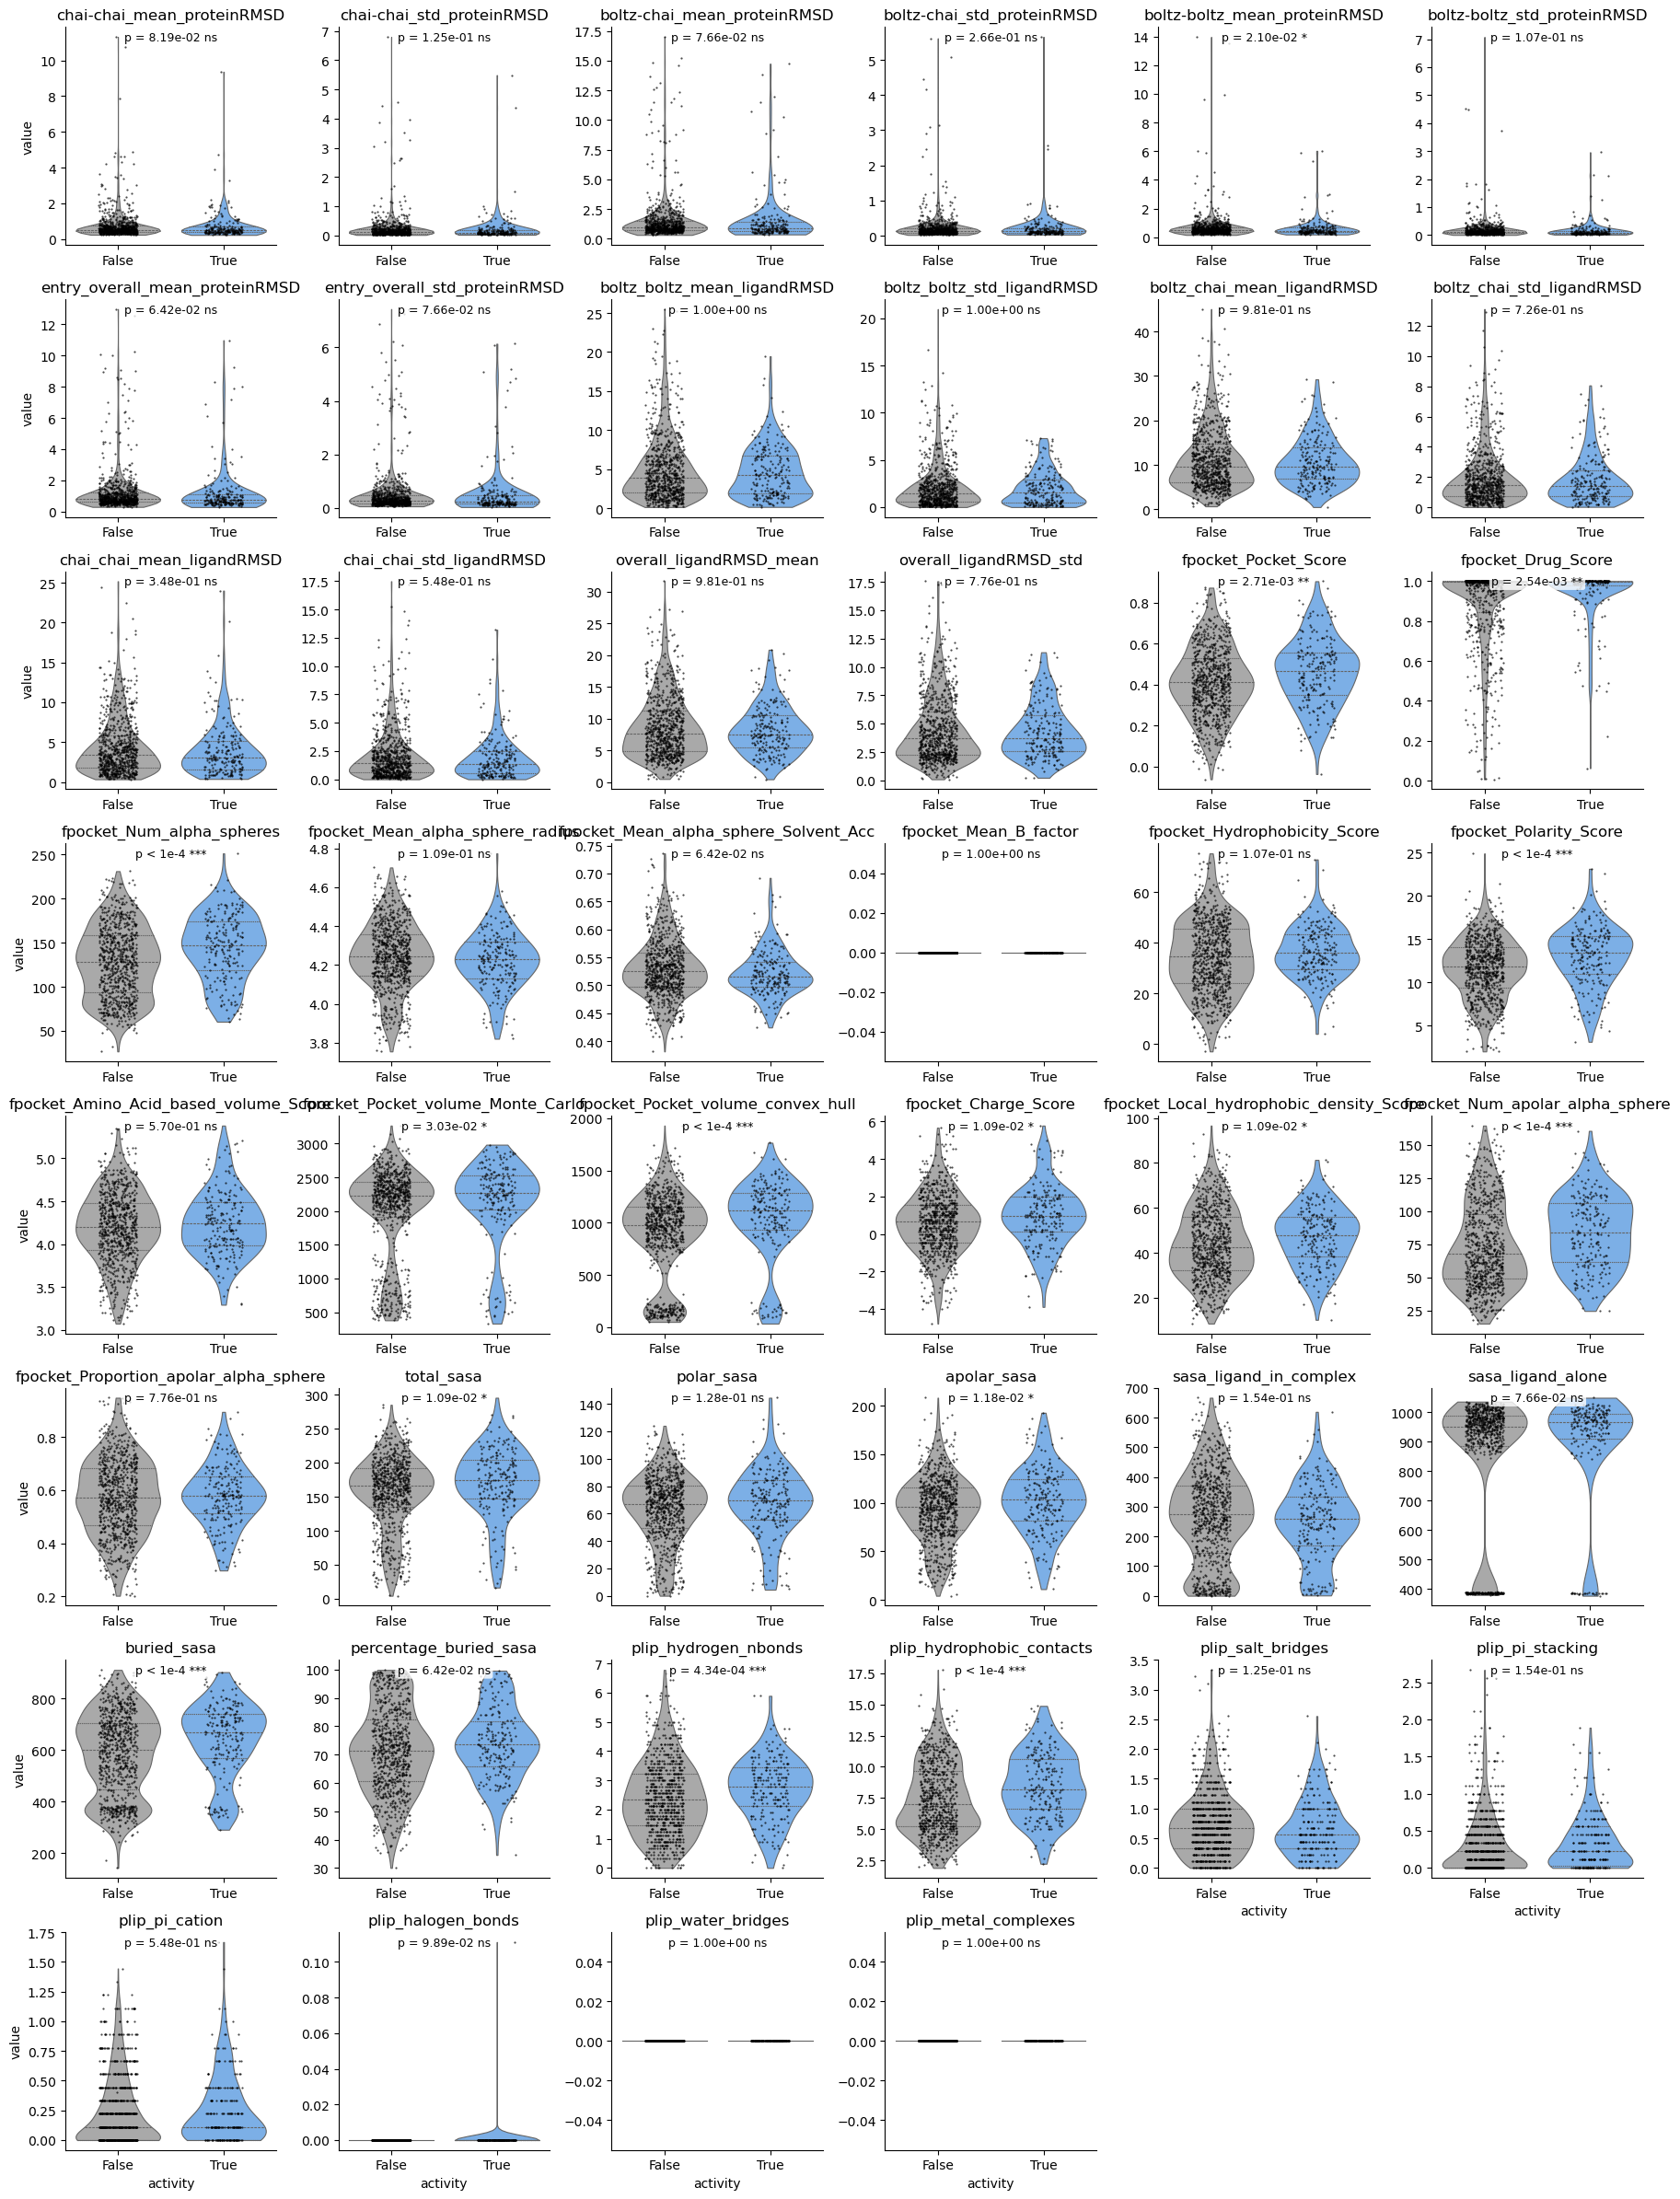

                              feature   p_value
26  fpocket_Pocket_volume_convex_hull  0.000002
18          fpocket_Num_alpha_spheres  0.000002
23             fpocket_Polarity_Score  0.000004
39          plip_hydrophobic_contacts  0.000004
36                        buried_sasa  0.000022


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap as tw

# stats
from scipy.stats import mannwhitneyu, ttest_ind, kruskal
try:
    from statsmodels.stats.multitest import multipletests
    _has_statsmodels = True
except Exception:
    _has_statsmodels = False

def _format_p(p):
    if p is None or np.isnan(p):
        return "p = n/a"
    if p < 1e-4:
        return "p < 1e-4 ***"
    stars = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    return f"p = {p:.2e} {stars}"

def violin_all_vs_activity_with_p(
    df, feature_columns, label_col="activity",
    col_wrap=4, height=3,
    overlay_jitter=0.18, overlay_size=1.6, overlay_alpha=0.7,
    test="mannwhitney",            # 'mannwhitney' | 'ttest' | 'auto'
    adjust="fdr_bh"                # 'fdr_bh' | None
):
    """
    Violin plots per feature vs. label with raw-point overlay and per-feature p-value.
    - For 2 classes: Mann–Whitney (default) or t-test if test='ttest'
    - For >2 classes: Kruskal–Wallis
    - adjust='fdr_bh' applies Benjamini–Hochberg (requires statsmodels)
    """
    # Long format
    df_long = (
        df[feature_columns + [label_col]]
        .melt(id_vars=[label_col], var_name="feature", value_name="value")
        .dropna(subset=["value"])
    )

    # Colors
    try:
        blue = pu.pastel_blue
    except Exception:
        blue = "#6baef7"

    cats = pd.Categorical(df_long[label_col]).categories.tolist()
    if len(cats) == 2:
        palette_map = {cats[0]: "darkgrey", cats[1]: blue}
    else:
        # fallback palette for multi-class
        palette_map = sns.color_palette("tab10", n_colors=len(cats))

    # ---- compute p-values per feature ----
    pvals = {}
    features_present = df_long["feature"].unique().tolist()

    for feat in features_present:
        sub = df_long.loc[df_long["feature"] == feat]
        groups = [sub.loc[sub[label_col] == c, "value"].dropna().values for c in cats]
        # drop empty groups
        groups = [g for g in groups if len(g) > 0]

        p = np.nan
        if len(groups) == 2:
            a, b = groups
            if len(a) > 0 and len(b) > 0:
                if test == "ttest":
                    p = ttest_ind(a, b, equal_var=False, nan_policy="omit").pvalue
                elif test == "auto":
                    # heuristic: if both groups fairly large and look normal-ish you might choose ttest;
                    # we keep it simple and use MWU:
                    p = mannwhitneyu(a, b, alternative="two-sided").pvalue
                else:
                    p = mannwhitneyu(a, b, alternative="two-sided").pvalue
        elif len(groups) > 2:
            # Kruskal–Wallis for k>2
            try:
                p = kruskal(*groups, nan_policy="omit").pvalue
            except Exception:
                p = np.nan

        pvals[feat] = p

    # Optional multiple testing correction
    if adjust and _has_statsmodels:
        feats = list(pvals.keys())
        raw = np.array([pvals[f] if pvals[f] is not None else np.nan for f in feats], dtype=float)
        mask = ~np.isnan(raw)
        if mask.sum() > 0:
            _, p_adj, _, _ = multipletests(raw[mask], method=adjust)
            for f, padj in zip(np.array(feats)[mask], p_adj):
                pvals[f] = float(padj)
    elif adjust and not _has_statsmodels:
        print("Warning: statsmodels not available; skipping multiple-testing correction.")

    # ---- plot violins ----
    g = sns.catplot(
        data=df_long,
        x=label_col, y="value",
        col="feature", col_wrap=col_wrap,
        kind="violin",
        hue=label_col,
        palette=palette_map,
        dodge=False,
        inner="quartile",
        cut=0,
        linewidth=0.8,
        height=height,
        sharex=True, sharey=False,
        legend=False
    )

    for key, ax in g.axes_dict.items():
        feat = key if isinstance(key, str) else key[-1]
        wrapped = tw.fill(str(feat).replace("_", " "), width=18)  # adjust width to taste
        ax.set_title(wrapped, fontsize=9, pad=10)

    # overlay raw points in black
    g.map_dataframe(
        sns.stripplot,
        x=label_col, y="value",
        color="black",
        jitter=overlay_jitter,
        size=overlay_size,
        alpha=overlay_alpha,
        dodge=False,
        linewidth=0
    )

    # annotate p on each facet, keep x ticks visible
    for key, ax in g.axes_dict.items():  # key is the facet value of "feature"
        feat = key if isinstance(key, str) else key[-1]
        ax.tick_params(axis='x', labelbottom=True)
        for lbl in ax.get_xticklabels():
            lbl.set_visible(True)
        ax.set_title(feat)

        # place p-value in the top center of the panel
        p = pvals.get(feat, np.nan)
        ax.text(0.5, 0.98, _format_p(p), transform=ax.transAxes,
                ha="center", va="top", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))

        # optional cleanup
        try:
            pu.clean_plt(ax)
        except Exception:
            pass

    g.set_axis_labels(label_col, "value")
    plt.tight_layout()
    plt.show()

    # return p-values for reference
    return pd.DataFrame({"feature": list(pvals.keys()), "p_value": list(pvals.values())})\
             .sort_values("p_value", na_position="last")


missing_columns = ['boltz2_affinity_pred_value', 'boltz2_affinity_probability_binary', 'boltz2_affinity_pred_value1', 'boltz2_affinity_probability_binary1', 'boltz2_affinity_pred_value2', 'boltz2_affinity_probability_binary2', 
                   'boltz2_chains_ptm', 'boltz2_pair_chains_iptm', 'chai_aggregate_score', 'chai_ptm', 'chai_iptm', 'boltz2_confidence_score', 'boltz2_ptm', 'boltz2_iptm', 'boltz2_ligand_iptm', 'boltz2_protein_iptm', 'boltz2_complex_plddt', 'boltz2_complex_iplddt', 'boltz2_complex_pde', 'boltz2_complex_ipde']

s2 = set(missing_columns)    
feature_columns = [x for x in feature_columns if x not in s2]

pvals_df = violin_all_vs_activity_with_p(
    results_df_avg_all,
    feature_columns,
    label_col="activity",
    col_wrap=6,
    height=3,
    test="mannwhitney",   # or 'ttest' or 'auto'
    adjust="fdr_bh"       # or None (requires statsmodels to apply)
)
print(pvals_df.head())


# To Do: 
# try linear regression or SVM -> linear kernel
# try random forest classifier
# train and test on different substrates (one substrate as a test set -> do all three)
# use kevin yangs dataset and run with pipeline



### Random forest classifier with leave-one-out crossvalidation of substrates

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
import numpy as np
import pandas as pd

# make a mapping Entry -> substrate_name (assuming it's consistent per Entry)
entry_to_substrate = (
    results_df[["Entry", "substrate_name"]]
    .drop_duplicates()
    .set_index("Entry")["substrate_name"]
)

# add substrate_name to the averaged df
results_df_avg_all["substrate_name"] = results_df_avg_all["Entry"].map(entry_to_substrate)

# features & labels (use the already-cleaned feature_columns)
X = results_df_avg_all[feature_columns].values
y = results_df_avg_all["activity"].values

# groups = substrate; this is the key fix
groups = results_df_avg_all["substrate_name"].values

print("Unique substrates used as groups:", np.unique(groups))

logo = LeaveOneGroupOut()
rf = RandomForestClassifier(
    n_estimators=500, 
    max_depth=None,
    random_state=42
)

results = []
probs_all = []
y_all = []
holdout_entries = []

for train_idx, test_idx in logo.split(X, y, groups=groups):
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    entry_test = np.unique(groups[test_idx])[0]  # one holdout Entry

    # Train model
    rf.fit(X_train, y_train)

    # Predictions
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:,1] if len(np.unique(y))==2 else None

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="binary" if len(np.unique(y))==2 else "macro")
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    results.append({
        "Entry": entry_test,
        "Accuracy": acc,
        "F1": f1,
        "AUC": auc
    })

    holdout_entries.append(entry_test)
    y_all.append(y_test)
    probs_all.append(y_prob)

results_df_cv = pd.DataFrame(results).sort_values("Entry")
print(results_df_cv)
print("\nMean performance:\n", results_df_cv.mean(numeric_only=True))




Unique substrates used as groups: ['act_4MUAc' 'probe' 'sing_4MUAc']
        Entry  Accuracy        F1       AUC
0   act_4MUAc  0.858696  0.000000  0.527778
1       probe  0.749695  0.080717  0.594016
2  sing_4MUAc  0.728261  0.000000  0.584776

Mean performance:
 Accuracy    0.778884
F1          0.026906
AUC         0.568857
dtype: float64


In [7]:
print(results_df_avg_all.groupby("substrate_name")["activity"].value_counts())


substrate_name  activity
act_4MUAc       False        90
                True          2
probe           False       640
                True        179
sing_4MUAc      False        67
                True         25
Name: count, dtype: int64


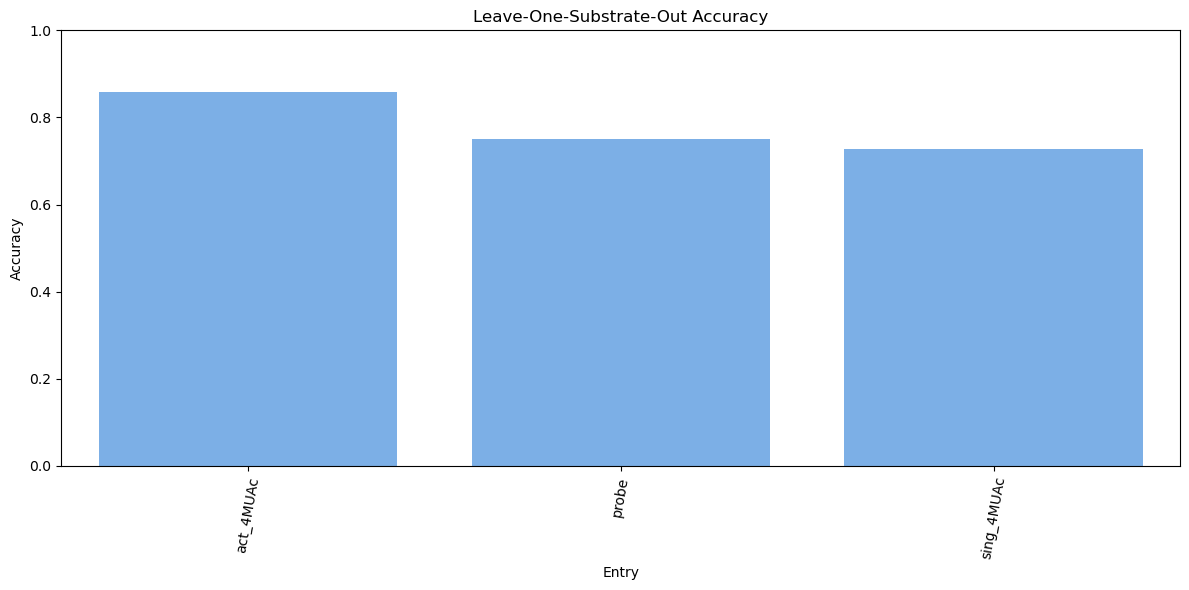

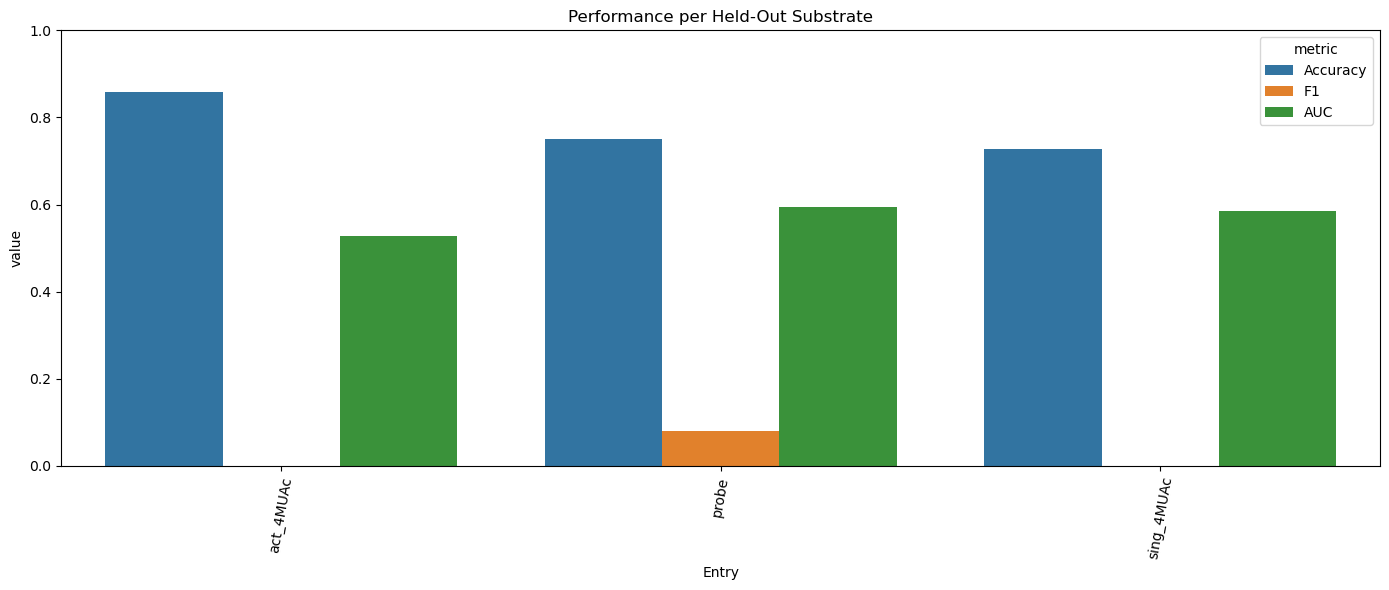

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(
    data=results_df_cv,
    x="Entry", y="Accuracy", color="#6baef7"
)
plt.xticks(rotation=80)
plt.title("Leave-One-Substrate-Out Accuracy")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

results_melted = results_df_cv.melt(id_vars="Entry", 
                                    value_vars=["Accuracy","F1","AUC"],
                                    var_name="metric", value_name="value")

plt.figure(figsize=(14,6))
sns.barplot(data=results_melted, x="Entry", y="value", hue="metric")
plt.ylim(0,1)
plt.xticks(rotation=80)
plt.title("Performance per Held-Out Substrate")
plt.tight_layout()
plt.show()


### Stratified 5-fold cross validation

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


   fold  Accuracy        F1       AUC
0     1  0.796020  0.088889  0.632774
1     2  0.810945  0.136364  0.647637
2     3  0.791045  0.086957  0.750524
3     4  0.795000  0.000000  0.724881
4     5  0.800000  0.090909  0.649486

Mean CV performance:
 fold        3.000000
Accuracy    0.798602
F1          0.080624
AUC         0.681061
dtype: float64


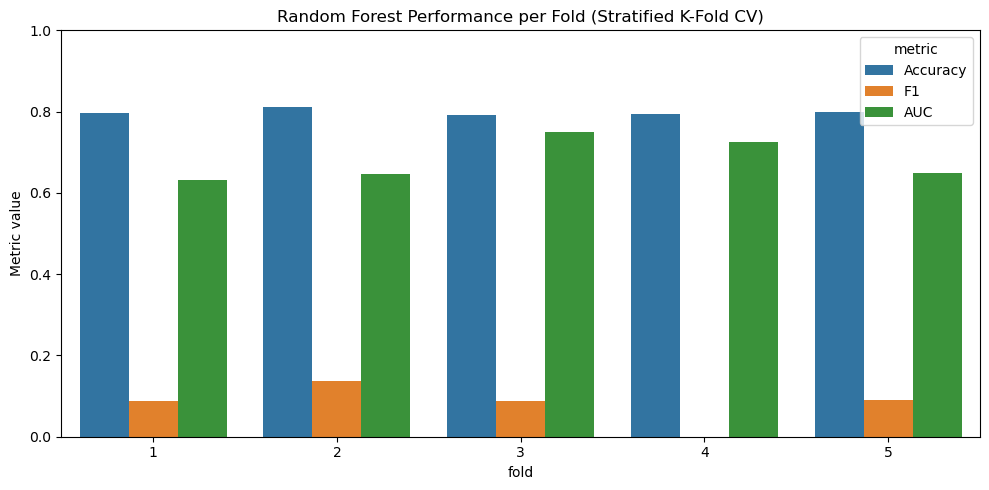

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

X = results_df_avg_all[feature_columns].values
y = results_df_avg_all["activity"].astype(int).values  # ensure 0/1

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",   # important for your imbalance
    n_jobs=-1,
    random_state=42
)

cv_rows = []
pred_rows = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="binary")
    auc = roc_auc_score(y_test, y_prob)

    cv_rows.append({
        "fold": fold,
        "Accuracy": acc,
        "F1": f1,
        "AUC": auc
    })

    fold_df = pd.DataFrame({
        "fold": fold,
        "Entry": results_df_avg_all.iloc[test_idx]["Entry"].values,
        "substrate_name": results_df_avg_all.iloc[test_idx]["substrate_name"].values,
        "y_true": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob
    })
    pred_rows.append(fold_df)

cv_results_df = pd.DataFrame(cv_rows)
predictions_df = pd.concat(pred_rows, ignore_index=True)

print(cv_results_df)
print("\nMean CV performance:\n", cv_results_df.mean(numeric_only=True))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
cv_results_long = cv_results_df.melt(id_vars="fold",
                                     var_name="metric",
                                     value_name="value")

sns.barplot(data=cv_results_long, x="fold", y="value", hue="metric")
plt.ylim(0,1)
plt.title("Random Forest Performance per Fold (Stratified K-Fold CV)")
plt.ylabel("Metric value")
plt.tight_layout()
plt.show()


### Stratified entry-wise K fold cross validation

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix
)
from sklearn.calibration import calibration_curve

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

cv_rows = []
pred_rows = []

fold = 0

for train_idx, test_idx in sgkf.split(X, y, groups):

    fold += 1

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="binary")
    auc = roc_auc_score(y_test, y_prob)

    cv_rows.append({
        "fold": fold,
        "Accuracy": acc,
        "F1": f1,
        "AUC": auc
    })

    # Store per-sample predictions
    fold_df = pd.DataFrame({
        "fold": fold,
        "Entry": results_df.iloc[test_idx]["Entry"].values,
        "substrate_name": results_df.iloc[test_idx]["substrate_name"].values,
        "y_true": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob
    })

    pred_rows.append(fold_df)

cv_results_df = pd.DataFrame(cv_rows)
predictions_df = pd.concat(pred_rows, ignore_index=True)

print(cv_results_df)
print("\nMean metrics:\n", cv_results_df.mean(numeric_only=True))

plt.figure(figsize=(10,5))
cv_results_long = cv_results_df.melt(id_vars="fold",
                                     var_name="metric",
                                     value_name="value")

sns.barplot(data=cv_results_long, x="fold", y="value", hue="metric")
plt.ylim(0,1)
plt.title("Random Forest Performance per Fold (Stratified K-Fold CV)")
plt.ylabel("Metric value")
plt.tight_layout()
plt.show()



ValueError: Found array with 0 sample(s) (shape=(0, 47)) while a minimum of 1 is required by RandomForestClassifier.

### Boxplots

sns.boxplot failed for feature boltz_chai_std_ligandRMSD: UnboundLocalError: cannot access local variable 'boxprops' where it is not associated with a value


/tmp/ipykernel_862729/2408392841.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_862729/2408392841.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.boxplot(


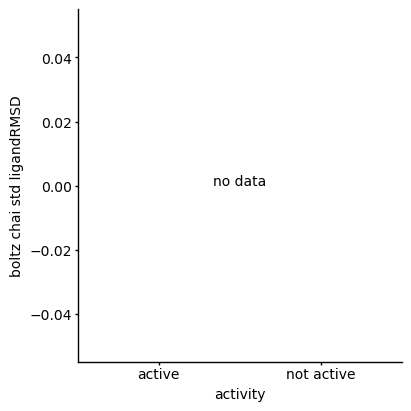

/tmp/ipykernel_862729/2408392841.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_862729/2408392841.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.boxplot(


sns.boxplot failed for feature chai_chai_std_ligandRMSD: UnboundLocalError: cannot access local variable 'boxprops' where it is not associated with a value


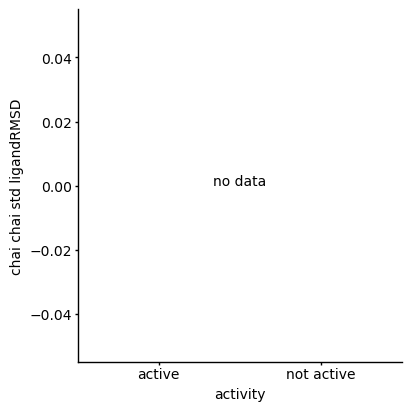

/tmp/ipykernel_862729/2408392841.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_862729/2408392841.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.boxplot(


sns.boxplot failed for feature boltz_boltz_std_ligandRMSD: UnboundLocalError: cannot access local variable 'boxprops' where it is not associated with a value


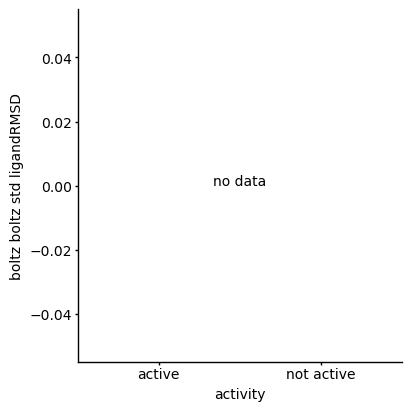

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def boxplot_features(
    df, features, *,
    label_col="activity",
    order=None,                 # None -> infer from data
    logy=False,
    figsize_scale=4,
    palette=None                # None -> auto colors
):
    """
    Box + strip plots for multiple features across classes in `label_col`.
    No statistical testing or p-values.
    """
    # validate features present
    valid = [f for f in features if f in df.columns]
    if not valid:
        raise ValueError("None of the requested features are in the DataFrame.")


    # determine classes and order
    classes = pd.Series(df[label_col]).dropna().unique().tolist()
    if order is None:
        order = sorted(classes) if pd.api.types.is_numeric_dtype(df[label_col]) else classes
    else:
        order = list(order)

    # coerce categorical with explicit order (prevents reindexing issues)
    df = df.copy()
    df[label_col] = pd.Categorical(df[label_col], categories=order, ordered=True)

    # auto palette
    if palette is None:
        n = len(order)
        if n == 2:
            palette = {order[0]: pastel_blue, order[1]: "darkgrey"}
        else:
            pal_list = sns.color_palette("tab20", n_colors=n)
            palette = {cls: pal_list[i] for i, cls in enumerate(order)}

    # ensure palette is a sequence matching `order` (avoid passing dict directly to sns.boxplot)
    if isinstance(palette, dict):
        palette_seq = [palette.get(cls, "grey") for cls in order]
    else:
        palette_seq = palette

    # layout
    n_feat = len(valid)
    ncols = min(3, max(1, n_feat))
    nrows = (n_feat + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(figsize_scale*ncols, figsize_scale*nrows),
        constrained_layout=True
    )
    axes = np.atleast_1d(axes).ravel()

    for i, feat in enumerate(valid):
        ax = axes[i]

        # Boxplot: try seaborn, fallback to matplotlib if seaborn raises an error
        try:
            # pass a sequence (palette_seq) rather than a dict to avoid seaborn internal legend code path
            sns.boxplot(
                data=df, x=label_col, y=feat,
                order=order, palette=palette_seq,
                ax=ax, showfliers=False, linewidth=1.2, width=0.6
            )
        except Exception as e:
            # catch seaborn/matplotlib internal errors (including UnboundLocalError) and fallback
            print(f"sns.boxplot failed for feature {feat}: {type(e).__name__}: {e}")
            # build data list in order
            data_list = [df.loc[df[label_col] == cls, feat].dropna().values for cls in order]
            # if all empty, continue
            if all(len(arr) == 0 for arr in data_list):
                ax.text(0.5, 0.5, 'no data', transform=ax.transAxes, ha='center')
            else:
                positions = list(range(1, len(order) + 1))
                bp = ax.boxplot(data_list, positions=positions, patch_artist=True, widths=0.6, showfliers=False)
                # color boxes
                for patch, color in zip(bp.get('boxes', []), palette_seq if palette_seq is not None else ["grey"] * len(order)):
                    try:
                        patch.set_facecolor(color)
                        patch.set_edgecolor('black')
                    except Exception:
                        pass
                # set xticks/labels to match categorical order
                ax.set_xticks(positions)
                ax.set_xticklabels(order)

        # Raw points in black on top
        # Use seaborn stripplot (works with categorical x); if it fails, fall back silently
        try:
            sns.stripplot(
                data=df, x=label_col, y=feat,
                order=order,
                ax=ax, color="black", alpha=0.25, size=3, jitter=True
            )
        except Exception:
            pass

        # axes formatting
        ax.set_xlabel(label_col)
        ax.set_ylabel(feat.replace("_", " "))
        if logy:
            ax.set_yscale("log")

        # simple legend with palette key only (build colors robustly whether original palette was dict or list)
        handles = []
        labels = []
        for idx, cls in enumerate(order):
            if isinstance(palette, dict):
                color = palette.get(cls, "grey")
            else:
                # palette_seq should be a list/sequence aligned with order
                color = palette_seq[idx] if (palette_seq is not None and idx < len(palette_seq)) else "grey"
            h = plt.Line2D([0], [0], marker='s', linestyle='',
                           markerfacecolor=color,
                           markeredgecolor='none', markersize=8)
            handles.append(h); labels.append(str(cls))
        # ax.legend(handles, labels, frameon=True, loc="upper right", title="")
        clean_plt(ax, max_label_chars=40)

    # remove any unused axes
    for j in range(len(valid), len(axes)):
        axes[j].remove()

    plt.show()
    return fig

# Average numeric columns per Entry
df_results_df_avg = results_df.groupby("Entry", as_index=False).mean(numeric_only=True)
# Add activity back 
activity_map = results_df.groupby("Entry")["activity"].first()
df_results_df_avg = df_results_df_avg.merge(activity_map, on="Entry", how="left")

fig = boxplot_features(
    df_results_df_avg,
    features=["boltz_chai_std_ligandRMSD"],
    label_col="activity",
    order=("active","not active")
)
fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/boxplot_boltz_chai_std_ligandRMSD_results_df_avg_all.png', dpi=300)

fig = boxplot_features(
    df_results_df_avg,
    features=["chai_chai_std_ligandRMSD"],
    label_col="activity",
    order=("active","not active")
)
fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/boxplot_chai_chai_std_ligandRMSD_results_df_avg_all.png', dpi=300)

fig = boxplot_features(
    df_results_df_avg,
    features=["boltz_boltz_std_ligandRMSD"],
    label_col="activity",
    order=("active","not active")
)
fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/boxplot_boltz_boltz_std_ligandRMSD_results_df_avg_all.png', dpi=300)


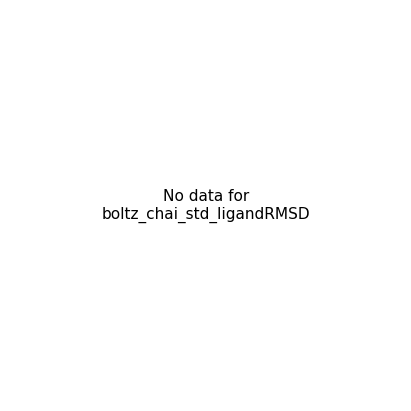

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define pastel_blue if not already defined
try:
    pastel_blue
except NameError:
    pastel_blue = "#aec7e8"


def boxplot_features(
    df, features, *,
    label_col="activity",
    order=None,
    logy=False,
    figsize_scale=4,
    palette=None
):
    """
    Robust box + strip plot generator for multiple features.
    Handles empty data, avoids seaborn legend bugs, and works with categorical labels.
    """

    # Validate features
    valid = [f for f in features if f in df.columns]
    if not valid:
        raise ValueError("None of the requested features exist in the DataFrame.")

    # Determine order of classes
    classes = pd.Series(df[label_col]).dropna().unique().tolist()
    if order is None:
        order = sorted(classes) if pd.api.types.is_numeric_dtype(df[label_col]) else classes
    else:
        order = list(order)

    # Categorical coercion
    df = df.copy()
    df[label_col] = pd.Categorical(df[label_col], categories=order, ordered=True)

    # ------- PALETTE HANDLING -------
    if palette is None:
        n = len(order)
        if n == 2:
            palette = {order[0]: pastel_blue, order[1]: "darkgrey"}
        else:
            pal_list = sns.color_palette("tab20", n_colors=n)
            palette = {cls: pal_list[i] for i, cls in enumerate(order)}

    if isinstance(palette, dict):
        palette_seq = [palette.get(cls, "grey") for cls in order]
    else:
        palette_seq = palette

    # ------- LAYOUT -------
    n_feat = len(valid)
    ncols = min(3, max(1, n_feat))
    nrows = (n_feat + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(figsize_scale * ncols, figsize_scale * nrows),
        constrained_layout=True
    )
    axes = np.atleast_1d(axes).ravel()

    # ------- PLOTTING LOOP -------
    for i, feat in enumerate(valid):
        ax = axes[i]

        # Extract just the two columns needed
        sub = df[[label_col, feat]].dropna()

        # If no valid data, show clean placeholder panel
        if sub.empty or sub[feat].dropna().empty:
            ax.text(0.5, 0.5, f"No data for\n{feat}",
                    ha="center", va="center", fontsize=11)
            ax.set_axis_off()
            continue

        # ---- BOX PLOT ----
        sns.boxplot(
            data=df, x=label_col, y=feat,
            order=order, palette=palette_seq,
            ax=ax, showfliers=False, linewidth=1.2, width=0.6,
            legend=False   # ← CRITICAL FIX
        )

        # ---- STRIP PLOT ----
        sns.stripplot(
            data=df, x=label_col, y=feat,
            order=order,
            color="black", alpha=0.25, size=3, jitter=True,
            ax=ax
        )

        # Labels
        ax.set_xlabel(label_col)
        ax.set_ylabel(feat.replace("_", " "))

        if logy:
            ax.set_yscale("log")

        # No legend for boxplots
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Remove unused axes
    for j in range(len(valid), len(axes)):
        axes[j].remove()

    return fig

fig = boxplot_features(
    df_results_df_avg,
    features=["boltz_chai_std_ligandRMSD"],
    label_col="activity",
    order=("active","not active")
)